## Examen Práctico - Segundo Parcial

**Imagen 1:** `histo_1.jpg`

### 0) Cargar una de las imágenes histológicas

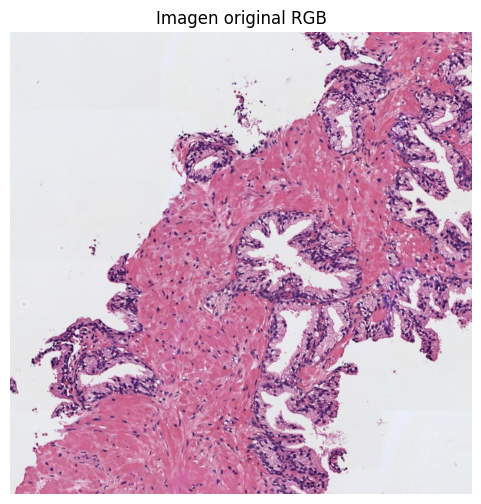

In [40]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology, segmentation, measure, util
from scipy.ndimage import binary_fill_holes
import pandas as pd
import math

ruta_imagen = "histo_1.jpg"
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
imagen_rgb = np.asarray(Image.open(ruta_imagen).convert("RGB")).astype(float) / 255.0

# Visualizar la imagen
plt.figure(figsize=(6,6))
plt.imshow(imagen_rgb)
plt.title("Imagen original RGB")
plt.axis("off")
plt.show()

### 1) Realizar una transformación de color para convertir la imagen al espacio CMYK

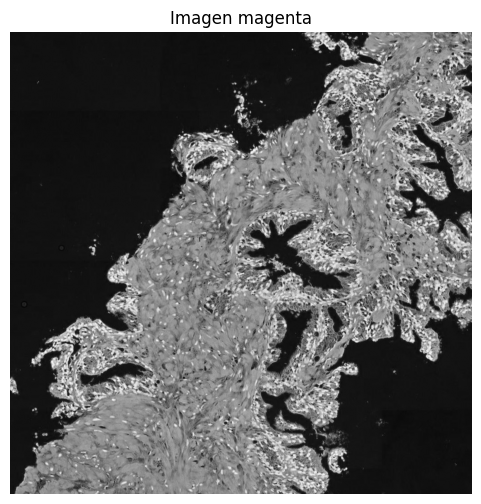

In [41]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
imagen_cmyk = np.asarray(Image.open(ruta_imagen).convert("CMYK")).astype(float) / 255.0
canal_magenta = imagen_cmyk[:, :, 1]

# Visualizar la imagen del canal magenta
plt.figure(figsize=(6,6))
plt.imshow(canal_magenta, cmap="gray")
plt.title("Imagen magenta")
plt.axis("off")
plt.show()

### 2) Umbralizar la imagen para separar el fondo y los lúmenes

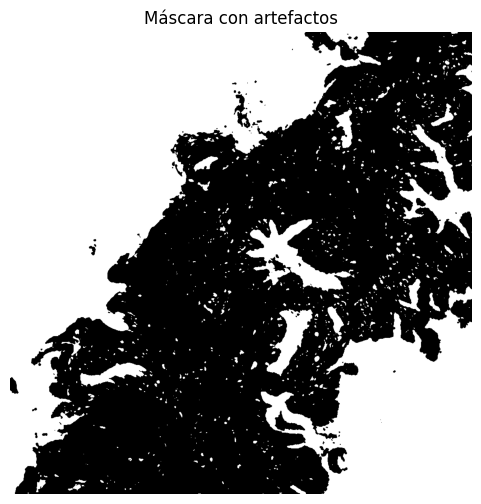

In [42]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
imagen_suavizada = filters.gaussian(canal_magenta, sigma=1, preserve_range=True)
imagen_uint8 = util.img_as_ubyte(imagen_suavizada)
umbral_otsu = filters.threshold_otsu(imagen_uint8)

# En esta máscara quedan en blanco el fondo y los lúmenes
mascara_con_artefactos = imagen_uint8 < umbral_otsu

# Visualizar la máscara resultante
plt.figure(figsize=(6,6))
plt.imshow(mascara_con_artefactos, cmap="gray")
plt.title("Máscara con artefactos")
plt.axis("off")
plt.show()

### 3) Limpiar la imagen eliminando artefactos pequeños

C:\Users\erick\AppData\Local\Temp\ipykernel_36244\3580185587.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_sin_artefactos = morphology.remove_small_objects(mascara_con_artefactos, min_size=300)


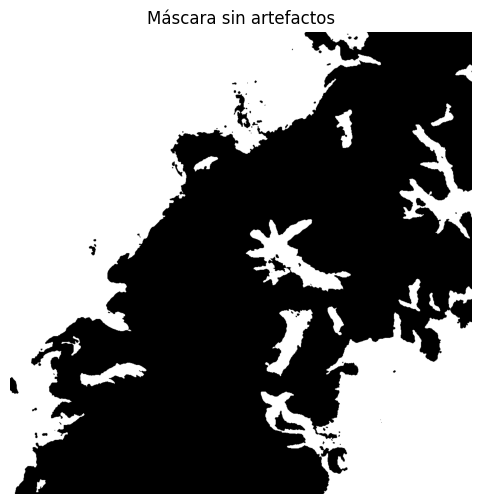

In [43]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
mascara_sin_artefactos = morphology.remove_small_objects(mascara_con_artefactos, min_size=300)

# Visualizaer la máscara resultante
plt.figure(figsize=(6,6))
plt.imshow(mascara_sin_artefactos, cmap="gray")
plt.title("Máscara sin artefactos")
plt.axis("off")
plt.show()

### 4) Rellenar con 0s el fondo para quedarnos solo con los lúmenes

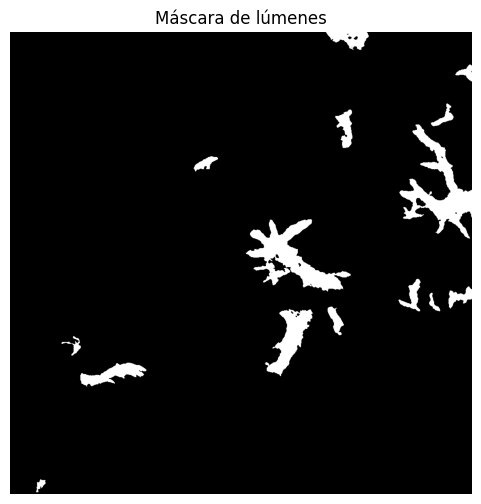

In [44]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
alto, ancho = mascara_sin_artefactos.shape
semillas = [(0, 0), (0, ancho-1), (alto-1, 0), (alto-1, ancho-1)]

mascara_fondo = np.zeros_like(mascara_sin_artefactos, dtype=bool)
for semilla in semillas:
    mascara_fondo |= segmentation.flood(mascara_sin_artefactos, semilla, tolerance=0)

mascara_lumenes = mascara_sin_artefactos & ~mascara_fondo

# Visualizar la máscara resultante. 
plt.figure(figsize=(6,6))
plt.imshow(mascara_lumenes, cmap="gray")
plt.title("Máscara de lúmenes")
plt.axis("off")
plt.show()

### 5) Rellenar los objetos de los lúmenes

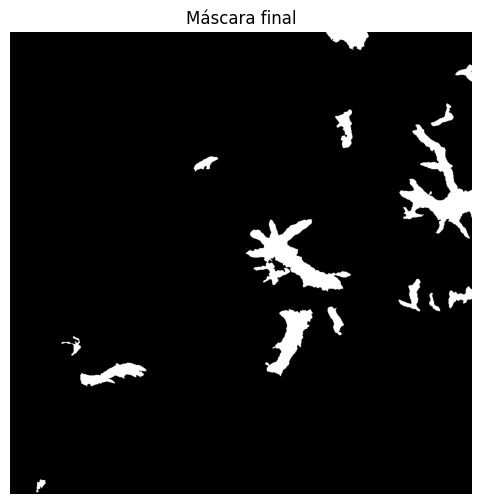

In [45]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
mascara_final = binary_fill_holes(mascara_lumenes)

# Visualizar la máscara resultante
plt.figure(figsize=(6,6))
plt.imshow(mascara_final, cmap="gray")
plt.title("Máscara final")
plt.axis("off")
plt.show()

### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

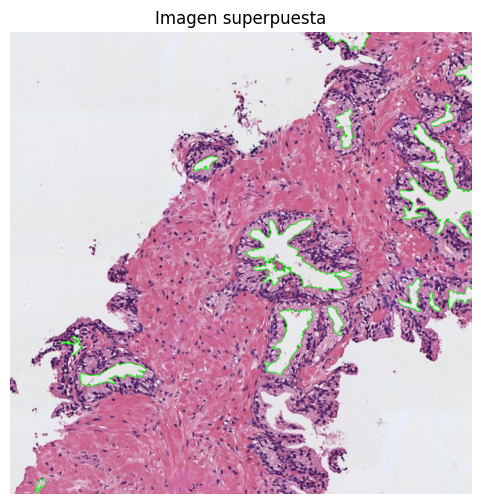

In [46]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
imagen_superpuesta = segmentation.mark_boundaries(imagen_rgb, mascara_final, color=(0, 1, 0), mode="thick")

# Visualizar la imagen superpuesta
plt.figure(figsize=(6,6))
plt.imshow(imagen_superpuesta)
plt.title("Imagen superpuesta")
plt.axis("off")
plt.show()

### 7) Identificar y cropear el lumen más grande

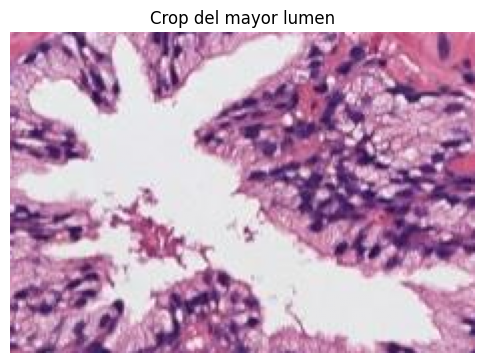

In [47]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
etiquetas = measure.label(mascara_final)
propiedades = sorted(measure.regionprops(etiquetas), key=lambda x: x.area, reverse=True)

lumen_mayor = propiedades[0]
min_fila, min_col, max_fila, max_col = lumen_mayor.bbox
crop_lumen_mayor = imagen_rgb[min_fila:max_fila, min_col:max_col]

# Visualizar el lumen cropeado.
plt.figure(figsize=(6,6))
plt.imshow(crop_lumen_mayor)
plt.title("Crop del mayor lumen")
plt.axis("off")
plt.show()

### 8) Extraer 13 características geométricas

In [48]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad
area = float(lumen_mayor.area)
area_bounding_box = float((max_fila - min_fila) * (max_col - min_col))
area_convexa = float(getattr(lumen_mayor, "area_convex", lumen_mayor.convex_area))
excentricidad = float(lumen_mayor.eccentricity)
diametro_equivalente = float(getattr(lumen_mayor, "equivalent_diameter_area", lumen_mayor.equivalent_diameter))
extension = float(lumen_mayor.extent)
diametro_feret = float(lumen_mayor.feret_diameter_max)
eje_mayor = float(lumen_mayor.axis_major_length)
eje_menor = float(lumen_mayor.axis_minor_length)
orientacion = float(lumen_mayor.orientation)
perimetro = float(lumen_mayor.perimeter)
solidez = float(lumen_mayor.solidity)
compacidad = float((4 * math.pi * area) / (perimetro ** 2))

tabla = pd.DataFrame({
    "Características": [
        "Área",
        "Área de la bounding box",
        "Área convexa",
        "Excentricidad",
        "Diámetro equivalente",
        "Extensión",
        "Diámetro Feret",
        "Longitud del eje mayor",
        "Longitud del eje menor",
        "Orientación",
        "Perímetro",
        "Solidez",
        "Compacidad"
    ],
    "Valor": [
        round(area, 4),
        round(area_bounding_box, 4),
        round(area_convexa, 4),
        round(excentricidad, 4),
        round(diametro_equivalente, 4),
        round(extension, 4),
        round(diametro_feret, 4),
        round(eje_mayor, 4),
        round(eje_menor, 4),
        round(orientacion, 4),
        round(perimetro, 4),
        round(solidez, 4),
        round(compacidad, 4)
    ]
})

tabla

C:\Users\erick\AppData\Local\Temp\ipykernel_36244\1736611526.py:17: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  area_convexa = float(getattr(lumen_mayor, "area_convex", lumen_mayor.convex_area))
C:\Users\erick\AppData\Local\Temp\ipykernel_36244\1736611526.py:19: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diametro_equivalente = float(getattr(lumen_mayor, "equivalent_diameter_area", lumen_mayor.equivalent_diameter))


,Características,Valor
0,Área,12647.0000
1,Área de la bounding box,37120.0000
2,Área convexa,27192.0000
3,Excentricidad,0.8508
4,Diámetro equivalente,126.8963
5,Extensión,0.3407
6,Diámetro Feret,242.0021
7,Longitud del eje mayor,235.8575
8,Longitud del eje menor,123.9524
9,Orientación,0.9857


## 5.   Github

https://github.com/Erick-305/machine-learning.git